# Import Libaries

In [27]:
import kagglehub
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from pathlib import Path
from soundfile import LibsndfileError
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# 0. Load data

In [28]:
path = kagglehub.dataset_download(
    "andradaolteanu/gtzan-dataset-music-genre-classification",
    output_dir="data"
)

print("Downloaded to:", path)
print(Path(path).resolve())

DATA_DIR = Path("data/Data/genres_original")

print("Path to dataset files:", DATA_DIR)

Downloaded to: data
D:\Programming_journey\portfolio\ai\ai-ml-portfolio\09-music-genre-classification\data
Path to dataset files: data\Data\genres_original


# 1. Data Inspection

## Genres

In [29]:
genres = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print("Number of genres:", len(genres))
print("Genres:", genres)

Number of genres: 10
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## Number of files in given genre

In [30]:
for genre in genres:
    files = list((DATA_DIR / genre).glob("*.wav"))
    print(f"{genre}: {len(files)}")

blues: 100
classical: 100
country: 100
disco: 100
hiphop: 100
jazz: 99
metal: 100
pop: 100
reggae: 100
rock: 100


## Create Data Frame

In [31]:
data = []

for genre in genres:
    for file in (DATA_DIR / genre).glob("*.wav"):
        data.append({
            "file_path": str(file),
            "genre": genre
        })

df = pd.DataFrame(data)

df.head()

,file_path,genre
0,data\Data\genres_original\blues\blues.00000.wav,blues
1,data\Data\genres_original\blues\blues.00001.wav,blues
2,data\Data\genres_original\blues\blues.00002.wav,blues
3,data\Data\genres_original\blues\blues.00003.wav,blues
4,data\Data\genres_original\blues\blues.00004.wav,blues


## Inspect All Audio Files in terms of Sample Rates and Duration

In [32]:
sample_rates = []
durations = []

for index, file_path in df["file_path"].copy().items():

    try:
        audio, sr = librosa.load(file_path, sr=None)

        df.loc[index, "sample_rate"] = sr
        df.loc[index, "duration"] = len(audio) / sr

    except LibsndfileError:
        print(f"Could not load: {file_path}")

        Path(file_path).unlink()
        df.drop(index, inplace=True)


df.reset_index(drop=True, inplace=True)

df.describe()

,sample_rate,duration
count,999.0,999.000000
mean,22050.0,30.024071
std,0.0,0.080951
min,22050.0,29.931973
25%,22050.0,30.000181
50%,22050.0,30.013333
75%,22050.0,30.013333
max,22050.0,30.648889


### Observation
All audio files have a consistent sample rate of **22,050 Hz** and an average duration of approximately **30 seconds**. The low standard deviation indicates that the audio files have very similar lengths.

# 2. Visualize Waveforms of Two Diffrent Genres

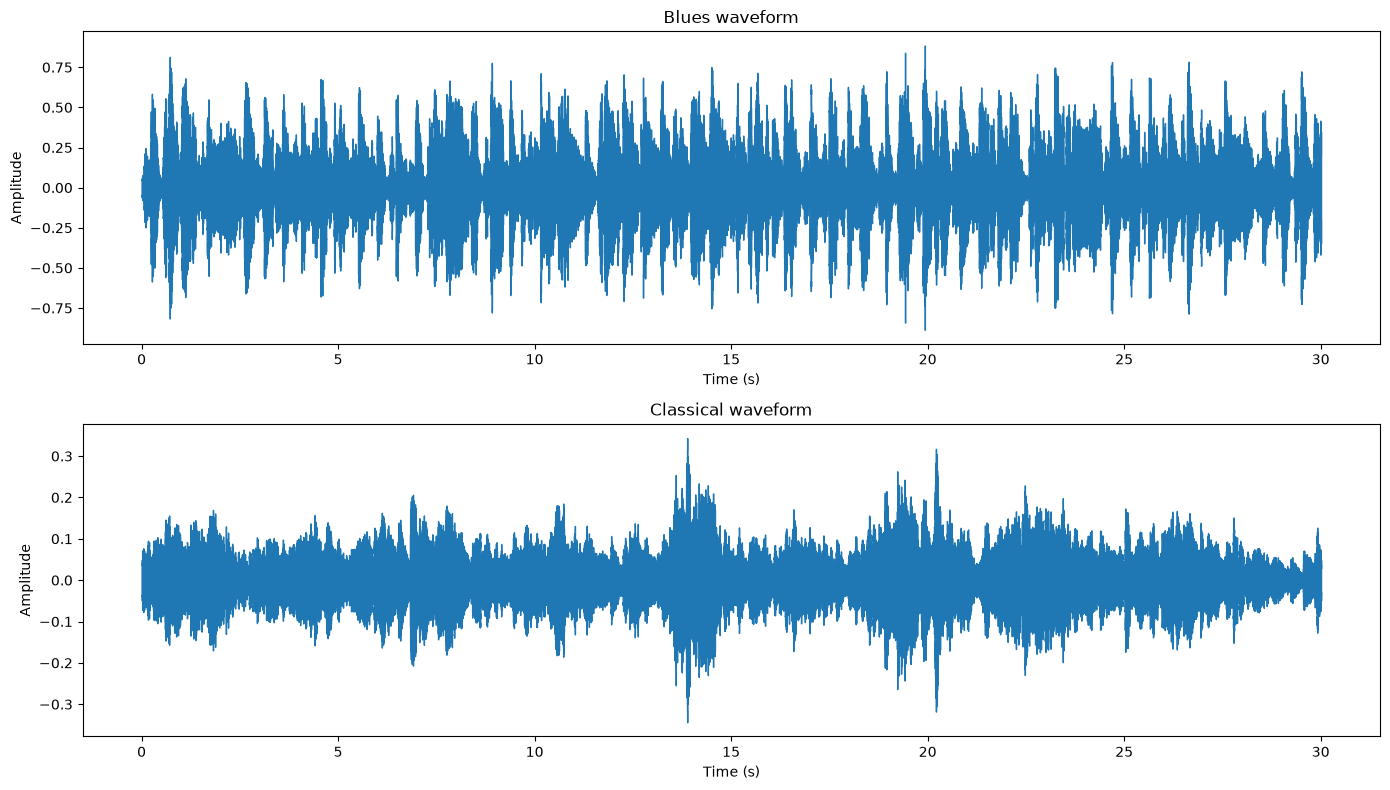

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, genre in zip(axes, ["blues", "classical"]):

    file_path = df[df["genre"] == genre].iloc[0]["file_path"]

    audio, sr = librosa.load(file_path, sr=None)

    librosa.display.waveshow(audio, sr=sr, ax=ax)

    ax.set_title(f"{genre.capitalize()} waveform")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Observation
The two waveforms show noticeable differences between the Blues and Classical samples. However, waveforms mainly represent amplitude over time, so they do not provide a clear representation of the frequency content of the music.

# 3. Create Spectrogram
Spectrograms show which frequencies occur in an audio signal and how their intensity changes over time. They are created using the **Short-Time Fourier Transform (STFT)**, which analyzes the frequencies in short segments of the audio.

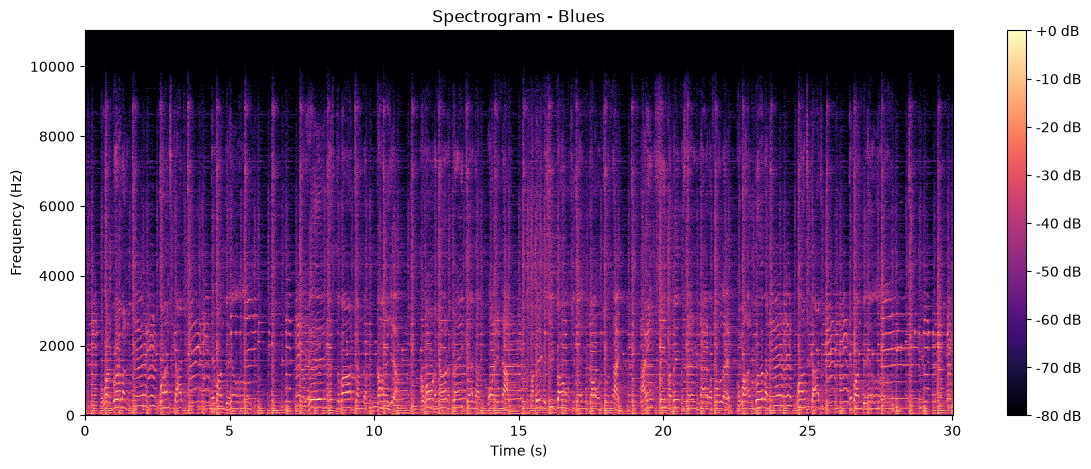

In [34]:
file_path = df.iloc[0]["file_path"]

audio, sr = librosa.load(file_path, sr=None)

# Short-Time Fourier Transform
stft = librosa.stft(audio)

# Convert complex values to amplitude
spectrogram = np.abs(stft)

# Convert amplitude to decibels
spectrogram_db = librosa.amplitude_to_db(
    spectrogram,
    ref=np.max
)

# Visualize spectrogram
plt.figure(figsize=(14, 5))

librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram - {df.iloc[0]['genre'].capitalize()}")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.show()

# 4. Create Mel Spectrogram with dB Scale
A Mel Spectrogram represents frequencies using the **Mel Scale**, which is designed to approximate human auditory perception. Converting the spectrogram to a **dB scale** makes differences in audio energy easier to visualize and analyze.

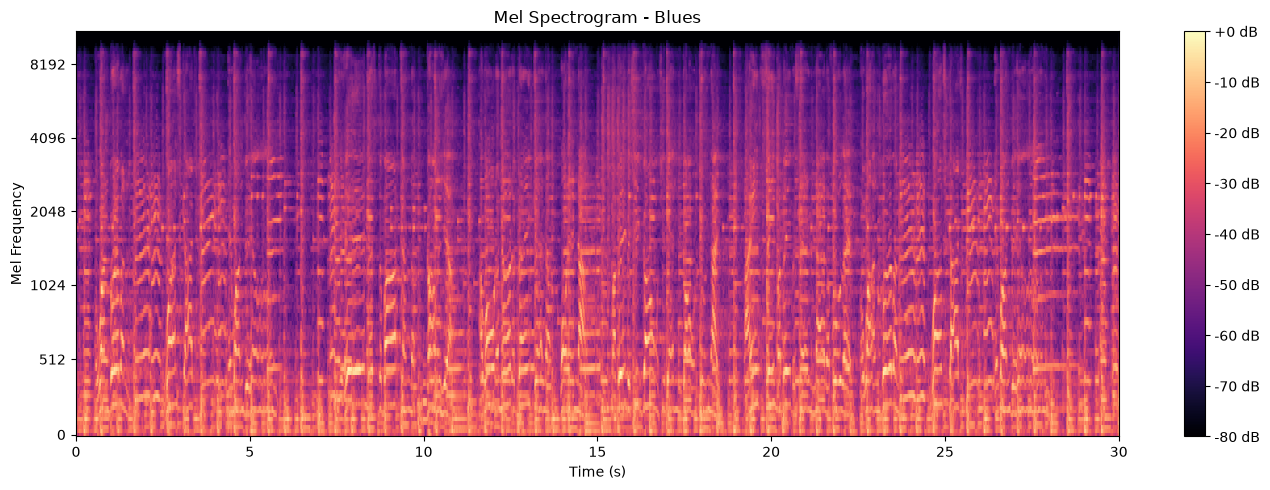

In [35]:
file_path = df.iloc[0]["file_path"]

audio, sr = librosa.load(file_path, sr=None)

mel_spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

mel_spectrogram_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_spectrogram_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title(
    f"Mel Spectrogram - {df.iloc[0]['genre'].capitalize()}"
)

plt.xlabel("Time (s)")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

# 5. Prepare Mel Spectrograms for CNN

## Function to Create Mel Spectrogram

In [36]:
def create_mel_spectrogram(file_path, pad=1292):

    audio, sr = librosa.load(file_path, sr=None)

    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft= 2048,
        hop_length= 512,
        n_mels=128,
    )

    mel_spectrogram_db = librosa.power_to_db(
        mel_spectrogram,
        ref=np.max
    )

    # Fix width
    if mel_spectrogram_db.shape[1] < pad:
        pad_width = pad - mel_spectrogram_db.shape[1]

        mel_spectrogram_db = np.pad(
            mel_spectrogram_db,
            ((0,0), (0, pad_width)),
            mode="constant"
        )

    else:
        mel_spectrogram_db = mel_spectrogram_db[:, :pad]

    # Normalize dB values to 0-1 using -80 dB as the lower limit
    mel_spectrogram_db = (mel_spectrogram_db + 80) / 80

    # Add channel dimension
    mel_spectrogram_db = mel_spectrogram_db[..., np.newaxis]


    return mel_spectrogram_db

mel = create_mel_spectrogram(df.iloc[0]["file_path"])

print(mel.shape)
print(mel)

(128, 1292, 1)
[[[0.5756802 ]
  [0.5894177 ]
  [0.55615985]
  ...
  [0.5734736 ]
  [0.61578476]
  [0.617483  ]]

 [[0.6109401 ]
  [0.64146006]
  [0.65977985]
  ...
  [0.599226  ]
  [0.6861495 ]
  [0.74245703]]

 [[0.5171771 ]
  [0.5242076 ]
  [0.6316527 ]
  ...
  [0.6402029 ]
  [0.6430268 ]
  [0.77281696]]

 ...

 [[0.        ]
  [0.        ]
  [0.        ]
  ...
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  ...
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  ...
  [0.        ]
  [0.        ]
  [0.        ]]]


### Info
Everything works.

## Create labels for genres

In [37]:
# label_encoder is an object that will handle the mapping from text to number.
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["genre"])

print(label_encoder.classes_)
print("Number of classes:", len(label_encoder.classes_))

['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Number of classes: 10


## Preparation of all data

In [38]:
X = []
y = []

for _, row in df.iterrows():

    mel = create_mel_spectrogram(row["file_path"])

    X.append(mel)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(999, 128, 1292, 1)
(999,)


# 6. Split the Data

In [39]:
# 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (799, 128, 1292, 1) (799,)
Validation: (100, 128, 1292, 1) (100,)
Test: (100, 128, 1292, 1) (100,)


# 7. Preapare Data for PyTorch

In [40]:
# Create torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Reordering of dimensions (samples, Mel, time, channel) => (samples, channel, Mel (H), time (W))
X_train = X_train.permute(0, 3, 1, 2)
X_val = X_val.permute(0, 3, 1, 2)
X_test = X_test.permute(0, 3, 1, 2)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([799, 1, 128, 1292])
X_val shape: torch.Size([100, 1, 128, 1292])
X_test shape: torch.Size([100, 1, 128, 1292])
y_train shape: torch.Size([799])
y_val shape: torch.Size([100])
y_test shape: torch.Size([100])


In [41]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 8. Create CNN

In [42]:
class MusicGenreCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        # Feature extraction
        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # Reduce spatial size by 2
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 128 x 16 x 161 → 128 x 4 x 4
            nn.AdaptiveAvgPool2d((4, 4))
        )

        # Classification
        self.classifier = nn.Sequential(

            # 128 x 4 x 4 → 2048
            nn.Flatten(),

            # 2048 → 128
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            # 128 → 10 classes
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [51]:
model = MusicGenreCNN(num_classes=10)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Training parameters
NUM_EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [52]:
for epoch in range(NUM_EPOCHS):

    # =========================
    # TRAIN
    # =========================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Store loss
        running_train_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()


    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)

            # Calculate loss
            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)

            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()


    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total


    # =========================
    # SAVE METRICS
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # PRINT RESULTS
    # =========================

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "best_music_genre_cnn.pth"
        )

        print("Best model saved.")

    else:

        patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # =========================
    # EARLY STOPPING
    # =========================

    if patience_counter >= PATIENCE:

        print("Early stopping triggered.")

        break

Epoch [1/50] | Train Loss: 2.2717 | Train Acc: 0.1352 | Val Loss: 2.1940 | Val Acc: 0.1800
Best model saved.
Epoch [2/50] | Train Loss: 2.0940 | Train Acc: 0.1990 | Val Loss: 2.0386 | Val Acc: 0.3000
Best model saved.
Epoch [3/50] | Train Loss: 2.0258 | Train Acc: 0.2753 | Val Loss: 1.9888 | Val Acc: 0.2900
Best model saved.
Epoch [4/50] | Train Loss: 1.9112 | Train Acc: 0.3079 | Val Loss: 1.9421 | Val Acc: 0.3300
Best model saved.
Epoch [5/50] | Train Loss: 1.8280 | Train Acc: 0.3217 | Val Loss: 1.8537 | Val Acc: 0.3700
Best model saved.
Epoch [6/50] | Train Loss: 1.7450 | Train Acc: 0.3642 | Val Loss: 1.8495 | Val Acc: 0.4000
Best model saved.
Epoch [7/50] | Train Loss: 1.6536 | Train Acc: 0.3705 | Val Loss: 1.9579 | Val Acc: 0.4200
No improvement. Patience: 1/5
Epoch [8/50] | Train Loss: 1.6302 | Train Acc: 0.3755 | Val Loss: 1.8389 | Val Acc: 0.3900
Best model saved.
Epoch [9/50] | Train Loss: 1.6155 | Train Acc: 0.4130 | Val Loss: 2.0024 | Val Acc: 0.3700
No improvement. Patience: